# Student Score Prediction - Exploratory Data Analysis

## 1. Problem Understanding
## 2. Load Dataset from SQLite
## 3. Initial Data Inspection
## 4. Missing Values and Data Quality
## 5. Target Variable Analysis
## 6. Numerical Feature Analysis
## 7. Categorical Feature Analysis
## 8. Time Feature Analysis
## 9. Feature-Target Relationships
## 10. Key EDA Findings
## 11. Implications for Machine Learning Pipeline

# Student Score Prediction - Exploratory Data Analysis

## 1. Problem Understanding

U.A Secondary School wants to predict students' O-level mathematics examination scores before the examination. The purpose is to identify weaker students early so that additional support can be provided.

This is a supervised regression problem because the target variable, `final_test`, is a continuous numerical examination score.

The main goals of this EDA are to:
1. Understand the structure and quality of the dataset.
2. Identify missing values, inconsistent categories, and possible outliers.
3. Explore relationships between student attributes and `final_test`.
4. Derive preprocessing and feature engineering decisions for the machine learning pipeline.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load Dataset from SQLite

The dataset is stored in a SQLite database. Loading the data through SQLite matches the expected data access pattern for the machine learning pipeline.

In [3]:
DB_PATH = Path("data/score.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM score", conn)
conn.close()

df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


In [ ]:
df.shape

(15900, 18)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 15900 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mode_of_transpo

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,15900.0,NaN,NaN,NaN,7949.5,4590.078975,0.0,3974.75,7949.5,11924.25,15899.0
number_of_siblings,15900.0,NaN,NaN,NaN,0.886541,0.751346,0.0,0.0,1.0,1.0,2.0
direct_admission,15900,2,No,11195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CCA,15900,8,Clubs,3912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
learning_style,15900,2,Auditory,9132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
student_id,15900,15000,AXZN2E,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,15900,2,Male,7984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tuition,15900,4,Yes,8669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final_test,15405.0,NaN,NaN,NaN,67.165401,13.977879,32.0,56.0,68.0,78.0,100.0
n_male,15900.0,NaN,NaN,NaN,13.88,6.552584,0.0,10.0,14.0,18.0,31.0


In [10]:
df.nunique().sort_values()

direct_admission          2
learning_style            2
gender                    2
number_of_siblings        3
mode_of_transport         3
tuition                   4
wake_time                 5
bag_color                 6
age                       6
CCA                       8
sleep_time               13
hours_per_week           21
n_male                   32
n_female                 32
attendance_rate          61
final_test               68
student_id            15000
index                 15900
dtype: int64

## 3. Initial Data Inspection

The dataset contains 15,900 rows and 18 columns. The target variable is `final_test`.

The columns can be grouped as follows:

- Identifier columns: `index`, `student_id`
- Target column: `final_test`
- Numerical features: `number_of_siblings`, `n_male`, `n_female`, `age`, `hours_per_week`, `attendance_rate`
- Categorical features: `direct_admission`, `CCA`, `learning_style`, `gender`, `tuition`, `mode_of_transport`, `bag_color`
- Time-based features: `sleep_time`, `wake_time`

`index` and `student_id` are identifiers rather than meaningful predictive features, so they should not be used directly in modelling.

In [12]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
attendance_rate,778,4.893082
final_test,495,3.113208
index,0,0.000000
n_female,0,0.000000
mode_of_transport,0,0.000000
wake_time,0,0.000000
sleep_time,0,0.000000
hours_per_week,0,0.000000
age,0,0.000000
n_male,0,0.000000


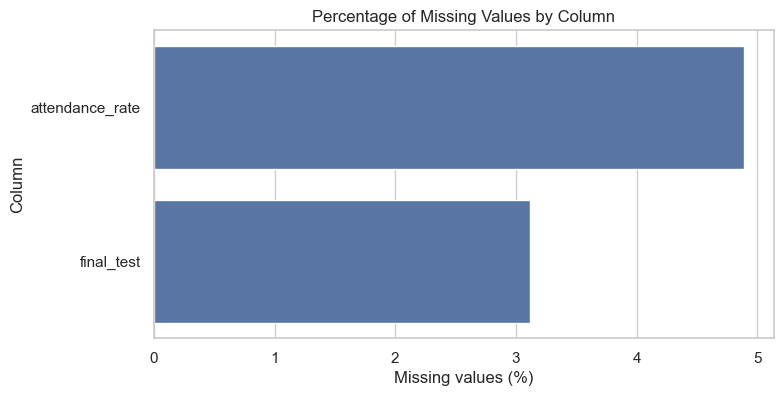

In [13]:
missing_summary_nonzero = missing_summary[missing_summary["missing_count"] > 0]

plt.figure(figsize=(8, 4))
sns.barplot(
    data=missing_summary_nonzero.reset_index(),
    x="missing_pct",
    y="index"
)
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Percentage of Missing Values by Column")
plt.show()


## 4. Missing Values and Data Quality

Only two columns contain missing values:

- `final_test`: missing target values
- `attendance_rate`: missing feature values

Rows with missing `final_test` cannot be used for supervised model training because the true label is unknown. These rows should be removed before training.

For `attendance_rate`, imputation should be handled inside the machine learning pipeline to avoid data leakage. The imputer should be fitted only on the training data.

In [15]:
df["student_id"].duplicated().sum()

np.int64(900)

In [16]:
duplicate_students = df[df["student_id"].duplicated(keep=False)].sort_values("student_id")
duplicate_students.head(10)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
5534,5534,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,green
12290,12290,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,white
12270,12270,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
13541,13541,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
4303,4303,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,yellow
9172,9172,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,green
8641,8641,0,No,Arts,Auditory,0FC4RY,Female,No,68.0,23.0,4.0,15.0,6.0,NaN,23:00,7:00,walk,blue
9791,9791,0,No,Arts,Auditory,0FC4RY,Female,No,68.0,23.0,4.0,15.0,6.0,100.0,23:00,7:00,walk,yellow
1405,1405,0,Yes,None,Visual,0JUGAF,Female,No,84.0,18.0,2.0,16.0,10.0,94.0,23:00,7:00,walk,red
6339,6339,0,Yes,None,Visual,0JUGAF,Female,No,84.0,18.0,2.0,16.0,10.0,94.0,23:00,7:00,walk,yellow


Some `student_id` values appear more than once. Since `student_id` is an identifier and may lead the model to memorise individual students rather than learn general patterns, it will be excluded from the modelling features.

The duplicated IDs should be noted as a data quality issue, but not used as a predictive signal.

In [17]:
df_labeled = df.dropna(subset=["final_test"]).copy()
df_labeled["final_test"].describe()

count    15405.000000
mean        67.165401
std         13.977879
min         32.000000
25%         56.000000
50%         68.000000
75%         78.000000
max        100.000000
Name: final_test, dtype: float64

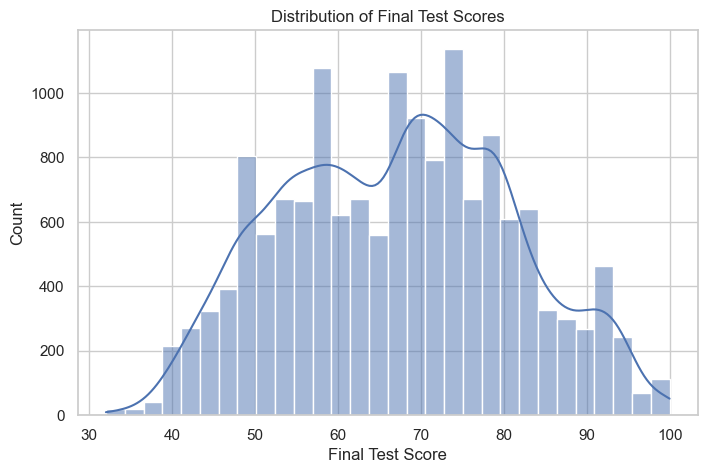

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df_labeled["final_test"], bins=30, kde=True)
plt.xlabel("Final Test Score")
plt.ylabel("Count")
plt.title("Distribution of Final Test Scores")
plt.show()

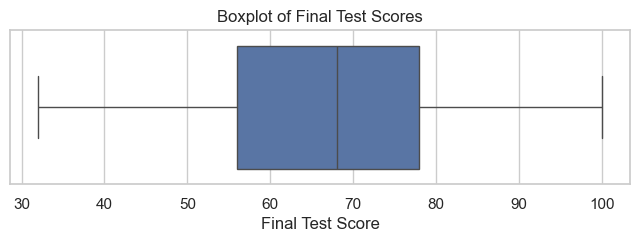

In [19]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df_labeled["final_test"])
plt.xlabel("Final Test Score")
plt.title("Boxplot of Final Test Scores")
plt.show()

## 5. Target Variable Analysis

The target variable `final_test` is a numerical score, confirming that this is a regression task.

The distribution should be inspected to understand the typical score range, spread, skewness, and possible outliers. This helps guide model selection and metric choice.

Since the school wants to identify weaker students, large prediction errors are especially important. Therefore, both MAE and RMSE should be considered during model evaluation.

In [20]:
numeric_cols = [
    "number_of_siblings",
    "n_male",
    "n_female",
    "age",
    "hours_per_week",
    "attendance_rate"
]

df_labeled[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_siblings,15405.0,0.886985,0.752139,0.0,0.0,1.0,1.0,2.0
n_male,15405.0,13.878935,6.547230,0.0,10.0,14.0,18.0,31.0
n_female,15405.0,8.903083,6.661095,0.0,4.0,8.0,13.0,31.0
age,15405.0,15.214346,1.757209,-5.0,15.0,15.0,16.0,16.0
hours_per_week,15405.0,10.312301,4.463029,0.0,7.0,9.0,14.0,20.0
attendance_rate,14648.0,93.265770,7.986489,40.0,92.0,95.0,97.0,100.0


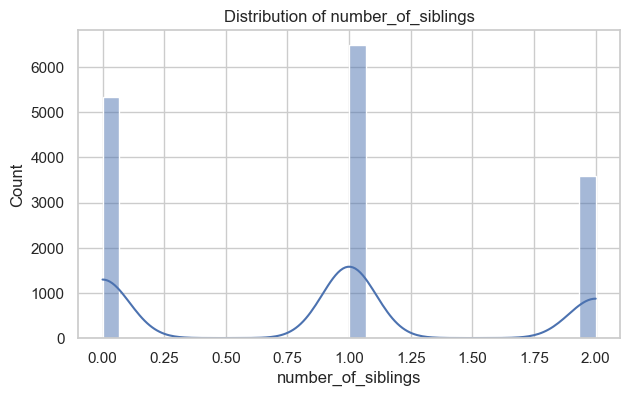

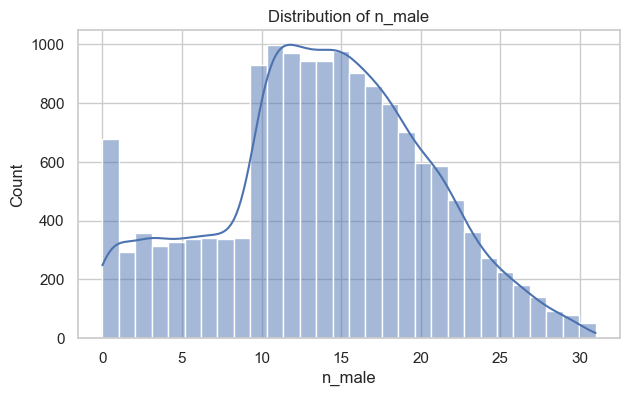

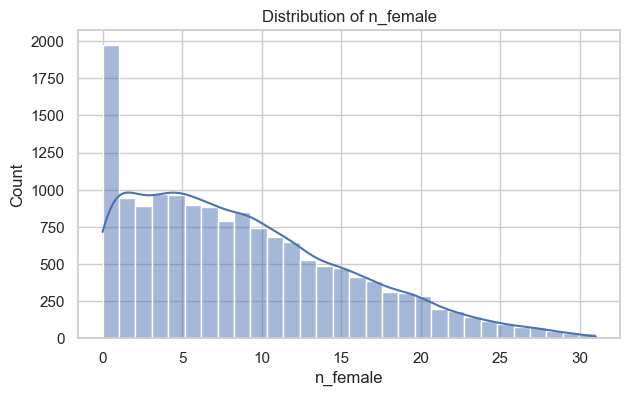

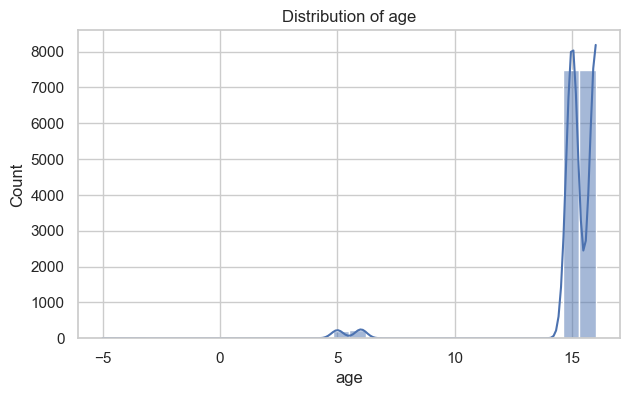

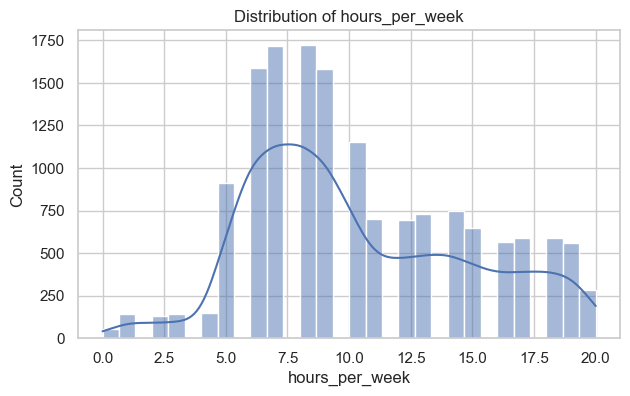

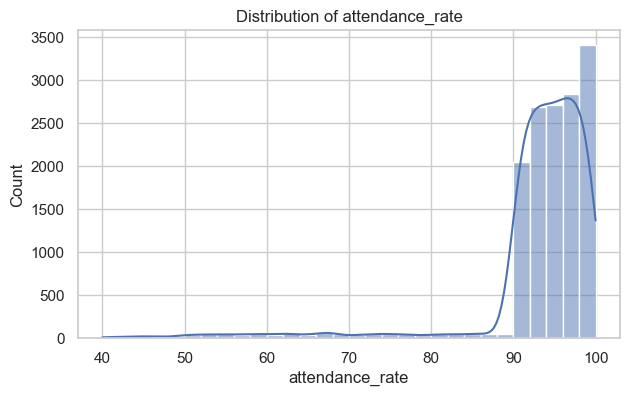

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_labeled[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

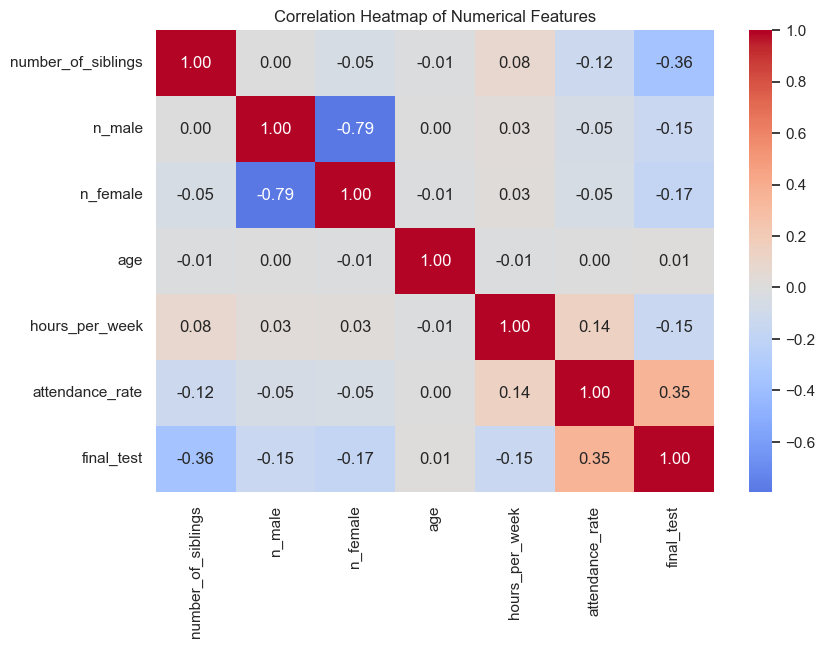

In [22]:
corr_cols = numeric_cols + ["final_test"]

plt.figure(figsize=(9, 6))
sns.heatmap(
    df_labeled[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 6. Numerical Feature Analysis

Numerical features were inspected to understand their distributions and linear associations with the target.

The correlation heatmap is useful for identifying features that may have predictive value for `final_test`. However, correlation only captures linear relationships and does not imply causation.

In [23]:
categorical_cols = [
    "direct_admission",
    "CCA",
    "learning_style",
    "gender",
    "tuition",
    "mode_of_transport",
    "bag_color"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df_labeled[col].value_counts(dropna=False))


direct_admission
direct_admission
No     10857
Yes     4548
Name: count, dtype: int64

CCA
CCA
Clubs     3803
Sports    3740
None      3707
Arts      3668
CLUBS      137
NONE       124
ARTS       123
SPORTS     103
Name: count, dtype: int64

learning_style
learning_style
Auditory    8847
Visual      6558
Name: count, dtype: int64

gender
gender
Male      7744
Female    7661
Name: count, dtype: int64

tuition
tuition
Yes    8403
No     6437
Y       313
N       252
Name: count, dtype: int64

mode_of_transport
mode_of_transport
public transport     6165
private transport    6146
walk                 3094
Name: count, dtype: int64

bag_color
bag_color
yellow    2658
black     2570
green     2555
blue      2550
red       2541
white     2531
Name: count, dtype: int64


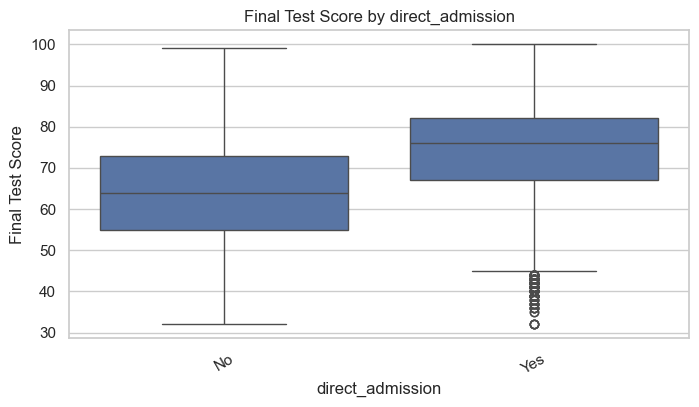

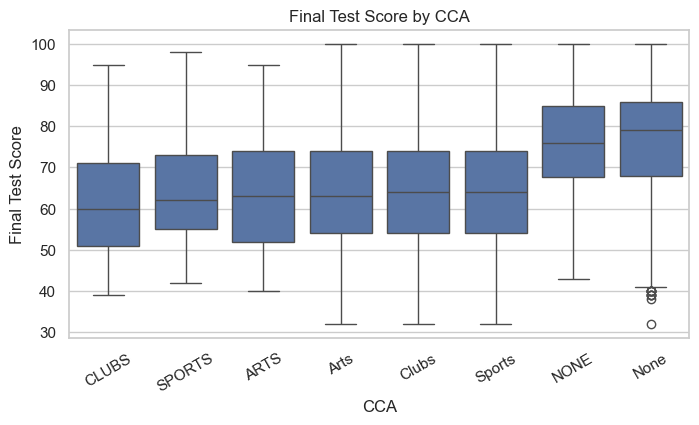

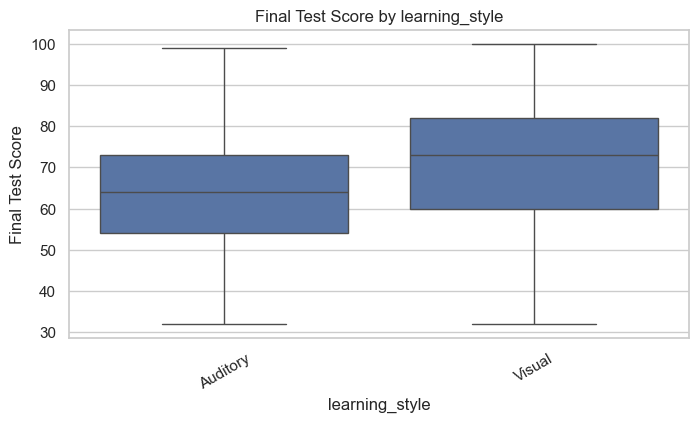

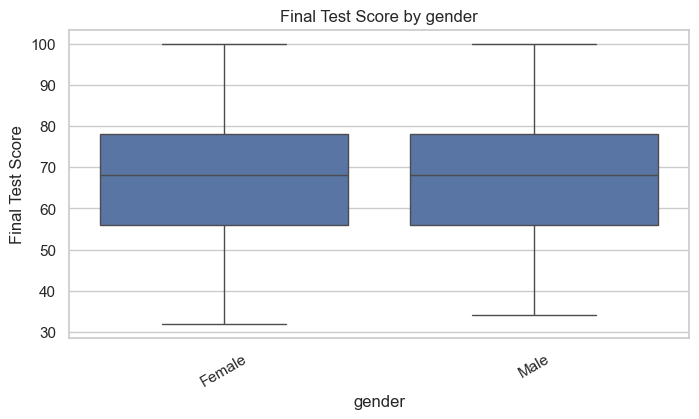

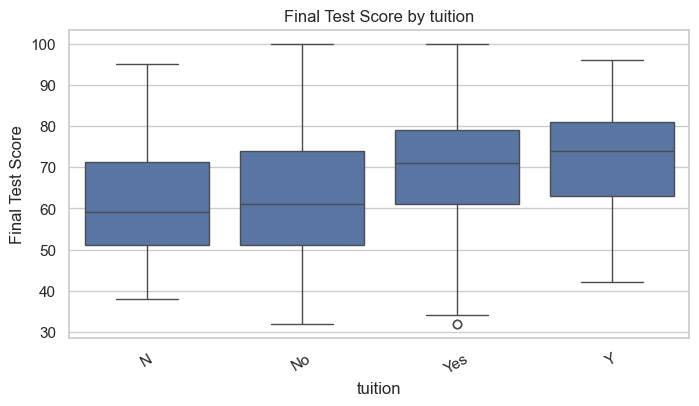

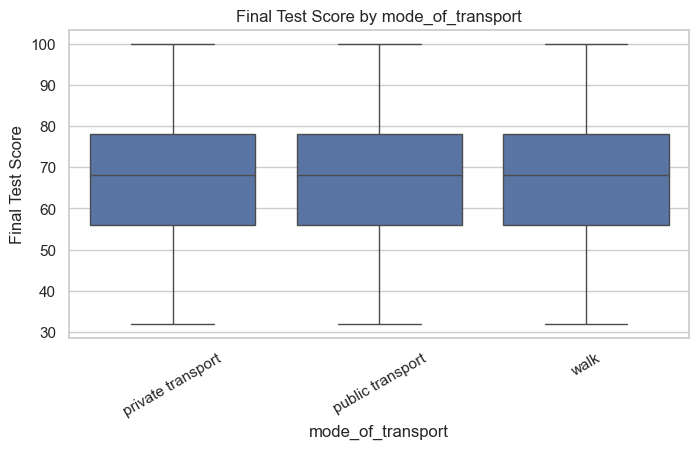

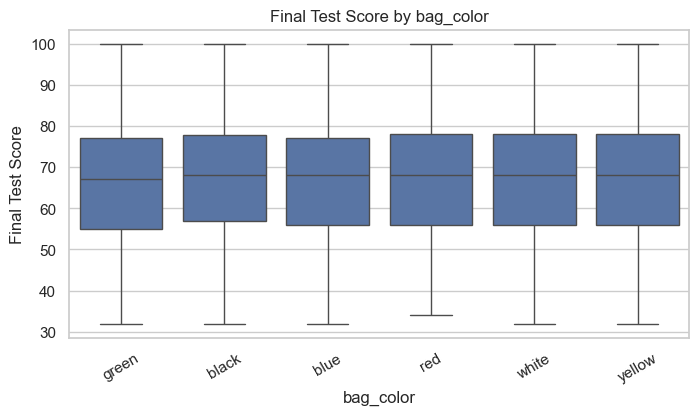

In [24]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df_labeled.groupby(col)["final_test"].median().sort_values().index
    sns.boxplot(data=df_labeled, x=col, y="final_test", order=order)
    plt.title(f"Final Test Score by {col}")
    plt.xlabel(col)
    plt.ylabel("Final Test Score")
    plt.xticks(rotation=30)
    plt.show()

## 7. Categorical Feature Analysis

Categorical features were examined using value counts and boxplots against `final_test`.

Several categorical columns contain inconsistent labels. For example, `tuition` contains both long-form and short-form labels, and `CCA` contains inconsistent casing. These should be standardised during preprocessing.

Boxplots help compare score distributions across categories, but observed differences should be interpreted as associations rather than causal effects.

In [25]:
def time_to_minutes(time_str):
    hour, minute = map(int, time_str.split(":"))
    return hour * 60 + minute

df_labeled["sleep_minutes"] = df_labeled["sleep_time"].apply(time_to_minutes)
df_labeled["wake_minutes"] = df_labeled["wake_time"].apply(time_to_minutes)

df_labeled["sleep_duration_hours"] = (
    (df_labeled["wake_minutes"] - df_labeled["sleep_minutes"]) % (24 * 60)
) / 60

df_labeled[["sleep_time", "wake_time", "sleep_duration_hours"]].head()

,sleep_time,wake_time,sleep_duration_hours
0,22:00,6:00,8.0
1,22:30,6:30,8.0
2,22:30,6:30,8.0
3,21:00,5:00,8.0
4,21:30,5:30,8.0


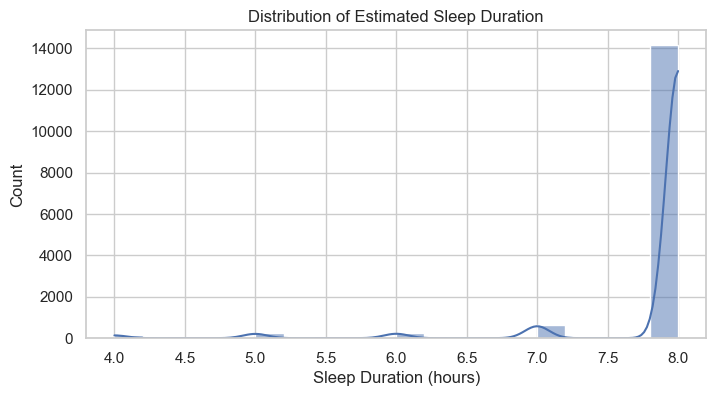

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(df_labeled["sleep_duration_hours"], bins=20, kde=True)
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Count")
plt.title("Distribution of Estimated Sleep Duration")
plt.show()

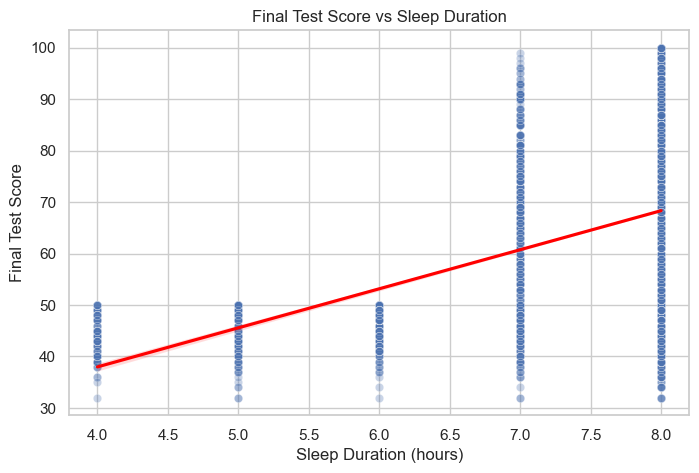

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_labeled,
    x="sleep_duration_hours",
    y="final_test",
    alpha=0.3
)
sns.regplot(
    data=df_labeled,
    x="sleep_duration_hours",
    y="final_test",
    scatter=False,
    color="red"
)
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Final Test Score")
plt.title("Final Test Score vs Sleep Duration")
plt.show()

## 8. Time Feature Analysis

`sleep_time` and `wake_time` are stored as strings. Instead of using the raw string values directly, they can be converted into a more meaningful feature: estimated sleep duration.

The sleep duration is computed using modular arithmetic to handle sleeping before midnight and waking up the next morning.

This engineered feature may be more useful for modelling than the raw sleep and wake time strings.

`sleep_time` and `wake_time` may contain information about both sleep duration and daily routine. For example, two students may sleep for the same number of hours but have very different sleep and wake timings. Therefore, I engineered `sleep_duration_hours`, while also retaining numerical representations of `sleep_time` and `wake_time` as `sleep_hour` and `wake_hour`.

In [29]:
for col in categorical_cols:
    display(
        df_labeled.groupby(col)["final_test"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median", ascending=False)
    )

,count,mean,median,std
direct_admission,,,,
Yes,4548,72.359719,76.0,14.035955
No,10857,64.989500,64.0,13.367099


,count,mean,median,std
CCA,,,,
None,3707,76.782304,79.0,12.161280
NONE,124,76.669355,76.0,11.967926
Clubs,3803,63.946621,64.0,12.950764
Sports,3740,64.056684,64.0,13.083986
ARTS,123,64.121951,63.0,13.891609
Arts,3668,64.059978,63.0,13.134873
SPORTS,103,63.504854,62.0,11.476211
CLUBS,137,61.189781,60.0,13.330931


,count,mean,median,std
learning_style,,,,
Visual,6558,71.586307,73.0,13.889588
Auditory,8847,63.888324,64.0,13.114772


,count,mean,median,std
gender,,,,
Female,7661,66.999869,68.0,14.045027
Male,7744,67.329158,68.0,13.910100


,count,mean,median,std
tuition,,,,
Y,313,72.009585,74.0,12.967040
Yes,8403,70.408664,71.0,12.835800
No,6437,62.909741,61.0,14.259212
N,252,61.706349,59.0,13.310911


,count,mean,median,std
mode_of_transport,,,,
private transport,6146,67.253010,68.0,14.018165
public transport,6165,67.099108,68.0,13.926842
walk,3094,67.123465,68.0,14.002827


,count,mean,median,std
bag_color,,,,
black,2570,67.358755,68.0,13.873970
blue,2550,67.114510,68.0,13.828498
red,2541,67.434475,68.0,13.960382
white,2531,67.144607,68.0,13.912361
yellow,2658,67.368698,68.0,14.143768
green,2555,66.563209,67.0,14.133115


In [30]:
df_labeled[numeric_cols + ["sleep_duration_hours", "final_test"]].corr()["final_test"].sort_values(ascending=False)

final_test              1.000000
attendance_rate         0.349375
sleep_duration_hours    0.327213
age                     0.014771
hours_per_week         -0.148254
n_male                 -0.149152
n_female               -0.171978
number_of_siblings     -0.363767
Name: final_test, dtype: float64

## 9. Feature-Target Relationships

The EDA suggests that some features may contain useful predictive signal, particularly attendance-related, study-related, and selected categorical variables.

However, the analysis is observational. The relationships should be treated as predictive associations, not causal claims.

Features with weak apparent signal, such as `bag_color`, may still be included initially through one-hot encoding, but model comparison and feature importance analysis can later help assess their usefulness.

## 10. Key EDA Findings

1. The task is a supervised regression problem with `final_test` as the target.
2. The dataset contains missing values in `final_test` and `attendance_rate`.
3. Rows with missing `final_test` should be excluded from supervised training.
4. `attendance_rate` should be imputed inside the ML pipeline to avoid data leakage.
5. `student_id` and `index` should be excluded as modelling features.
6. Some categorical variables contain inconsistent labels and require cleaning.
7. `sleep_time` and `wake_time` may capture both sleep duration and daily routine. Therefore, they can be converted into `sleep_duration_hours`, `sleep_hour`, and `wake_hour` instead of being used as raw string values.
8. Numerical and categorical features show varying degrees of association with `final_test`, but no causal conclusions should be drawn.

## 11. Implications for Machine Learning Pipeline

Based on the EDA, the machine learning pipeline should:

- Load data from SQLite.
- Remove rows where `final_test` is missing.
- Drop identifier columns such as `index` and `student_id`.
- Clean inconsistent categorical labels.
- Engineer time-based features from `sleep_time` and `wake_time`, including `sleep_duration_hours`, `sleep_hour`, and `wake_hour`.
- Split data into training and test sets before fitting preprocessors.
- Use a `ColumnTransformer` to handle numerical and categorical features.
- Impute missing numerical values, especially `attendance_rate`.
- One-hot encode categorical features.
- Compare at least three regression models against a baseline.
- Evaluate models using MAE, RMSE, and R².

- Standardise numerical features inside the pipeline where appropriate, especially for linear models such as Ridge Regression.

Primary: MAE
Secondary: RMSE, R²
Optional: RAE if you want to compare against baseline

The purpose of EDA was to understand the dataset before modelling. I checked the data shape, feature types, missing values, duplicated identifiers, inconsistent categorical labels, target distribution, outliers, and feature-target relationships. The EDA helped me decide which columns to drop, which values to clean, how to handle missing data, what feature engineering to apply, and which evaluation metrics were appropriate.